# Grover's Algorithm: Quantum Search in Qiskit

Imagine searching for a specific item in an unsorted database of $N$ elements. A classical computer would have to check all $N$ items in the worst case. Grover's algorithm solves this problem with a quadratic speedup: it only needs $O(\sqrt{N})$ steps.

In this educational notebook, we will demonstrate a fully generalized implementation. You can set an arbitrary number of qubits and the target state. The notebook will dynamically generate the corresponding **Oracle** and **Diffuser**, and calculate the optimal number of iterations needed to achieve the maximum measurement probability.

## 1. Import Libraries and Set Parameters
Here you can adjust the number of qubits and the specific state you want to find. For example, for 3 qubits, you can search for the state '101'.

In [6]:
# Import basic Qiskit tools
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import ZGate
import math
import matplotlib.pyplot as plt

# === ALGORITHM SETTINGS ===
# Try changing these values (e.g., num_qubits = 3, target_state = '101')
num_qubits = 3
target_state = '101'
# ==========================

## 2. Quantum Oracle
The oracle marks our target state by inverting its phase. Since the basic Multi-Controlled Z gate only marks the state of all ones ($|11..1\rangle$), we use **X gates** to temporarily flip the zeros in our `target_state` to ones before applying the Z gate.

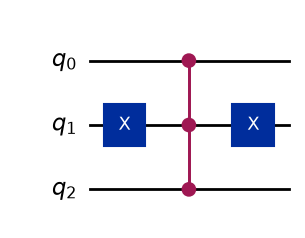

In [7]:
def create_oracle(num_qubits, target_state):
    """
    Creates a quantum circuit representing the oracle for an arbitrary number of qubits.
    """
    if len(target_state) != num_qubits:
        raise ValueError(f"Error: The target state '{target_state}' does not match the number of qubits ({num_qubits}).")

    oracle = QuantumCircuit(num_qubits, name=f' Oracle {target_state}')
    
    # Step 1: Flip qubits where the target state has a '0'
    for qubit, bit in enumerate(reversed(target_state)):
        if bit == '0':
            oracle.x(qubit)
            
    # Step 2: Mark the state (Multi-Controlled Z)
    if num_qubits == 1:
        oracle.z(0)
    elif num_qubits == 2:
        oracle.cz(0, 1)
    else:
        # Z gate controlled by (num_qubits - 1) qubits
        mcz = ZGate().control(num_qubits - 1)
        oracle.append(mcz, list(range(num_qubits)))
    
    # Step 3: Return qubits to their original state (uncompute)
    for qubit, bit in enumerate(reversed(target_state)):
        if bit == '0':
            oracle.x(qubit)
            
    return oracle

# Draw the generated Oracle for visual inspection
oracle_qc = create_oracle(num_qubits, target_state)
display(oracle_qc.draw('mpl'))

## 3. Amplitude Amplification (Diffuser)
While the oracle changes the phase of the target solution, the **diffuser** reflects all amplitudes about their mean. This causes the probability of measuring the target state to increase dramatically. 

This operation (inversion about the mean) is applied independently of the target state. It consists of a layer of Hadamard gates, X gates, and one Multi-Controlled Z operation.

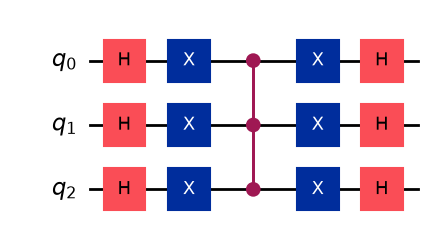

In [8]:
def create_diffuser(num_qubits):
    """
    Creates a diffuser circuit for an arbitrary number of qubits.
    """
    diffuser = QuantumCircuit(num_qubits, name=' Diffuser')
    
    # 1. Apply Hadamard gates to all qubits
    diffuser.h(range(num_qubits))
    
    # 2. Apply X gates to all qubits
    diffuser.x(range(num_qubits))
    
    # 3. Apply Multi-Controlled Z gate
    if num_qubits == 1:
        diffuser.z(0)
    elif num_qubits == 2:
        diffuser.cz(0, 1)
    else:
        mcz = ZGate().control(num_qubits - 1)
        diffuser.append(mcz, list(range(num_qubits)))
        
    # 4. Invert steps 2 and 1
    diffuser.x(range(num_qubits))
    diffuser.h(range(num_qubits))
    
    return diffuser

# Draw the diffuser
diffuser_qc = create_diffuser(num_qubits)
display(diffuser_qc.draw('mpl'))

## 4. Building the Grover Circuit
For multiple qubits, applying the Oracle + Diffuser combination just once is usually not enough. The optimal number of iterations depends on the size of the search space and is approximately $\frac{\pi}{4} \sqrt{2^N}$. The code below calculates this dynamically.

For 3 qubits, we perform 2 iteration(s).


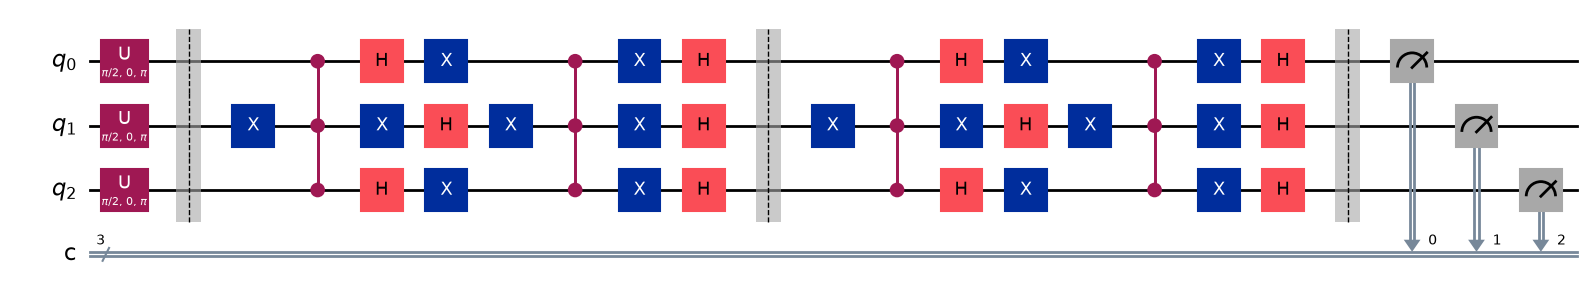

In [9]:
# Calculate the optimal number of iterations (approx. pi/4 * sqrt(N))
num_iterations = math.floor((math.pi / 4) * math.sqrt(2 ** num_qubits))
print(f"For {num_qubits} qubits, we perform {num_iterations} iteration(s).")

# Create the main quantum circuit
grover_circuit = QuantumCircuit(num_qubits, num_qubits)

# Initialization: Create a uniform superposition of all possible states
grover_circuit.h(range(num_qubits))
grover_circuit.barrier()

# Repeat the Oracle + Diffuser blocks based on the optimal count
for i in range(num_iterations):
    grover_circuit.append(create_oracle(num_qubits, target_state), range(num_qubits))
    grover_circuit.append(create_diffuser(num_qubits), range(num_qubits))
    grover_circuit.barrier()

# Measurement
grover_circuit.measure(range(num_qubits), range(num_qubits))

# Draw the assembled circuit (decomposed for clarity)
display(grover_circuit.decompose().draw('mpl'))

## 5. Simulation and Results
Let's run our quantum circuit on a simulator and look at the measurement probabilities. We must first transpile the circuit so the simulator understands our custom Oracle and Diffuser instructions. The marked target state should massively dominate the histogram.

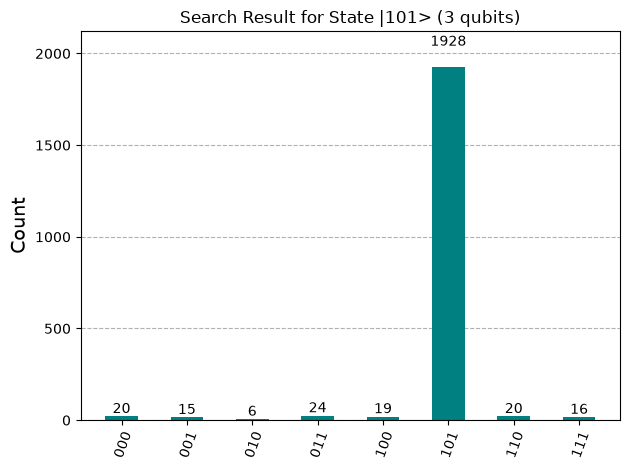

In [10]:
# Initialize the local simulator
simulator = AerSimulator()

# Step 1: Transpile the circuit for the simulator
transpiled_circuit = transpile(grover_circuit, simulator)

# Step 2: Run the transpiled circuit
result = simulator.run(transpiled_circuit, shots=2048).result()
counts = result.get_counts(transpiled_circuit)

# Plot the resulting histogram
display(plot_histogram(counts, title=f"Search Result for State |{target_state}> ({num_qubits} qubits)", color='teal'))